# EDA

In [10]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv ("Loan_Default.csv")

#Viewing Data

In [12]:
df.head() # show first five rows of data

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [13]:
df.tail() # show last five rows of data

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0
148669,173559,2019,cf,Female,nopre,type1,p3,l1,nopc,nob/c,...,CIB,830,CIB,45-54,not_inst,72.849462,North,direct,0,44.0


In [14]:
df.shape #shows no of rows and columns

(148670, 34)

In [19]:
df.info() #shows datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

#Counting Numerical and categorical columns

In [20]:
num_cols = df.select_dtypes(include=['number']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 13
Categorical columns: 21


#Find Values Count

In [21]:
cat_cols = df.select_dtypes(include=['object']).columns

def valuesCount(cat_cols):
    for col in cat_cols:
        print("\n--------------------")
        print("Column:", col)
        print("--------------------")
        print(df[col].value_counts())
       

In [22]:
valuesCount(cat_cols)


--------------------
Column: loan_limit
--------------------
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64

--------------------
Column: Gender
--------------------
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

--------------------
Column: approv_in_adv
--------------------
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64

--------------------
Column: loan_type
--------------------
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

--------------------
Column: loan_purpose
--------------------
loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64

--------------------
Column: Credit_Worthiness
--------------------
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

--------------------
Column: open_credit
--------------------
open_credit
nopc    148114
opc        5

#Finding Missing Values

In [23]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

#Statistical Analysis

In [24]:
df.describe() #Only for numerical Columns

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


#Visulization:
Numerical distributions → histograms
Categorical distributions → count plots
Outliers → boxplots
Target (Status) distribution → count plot

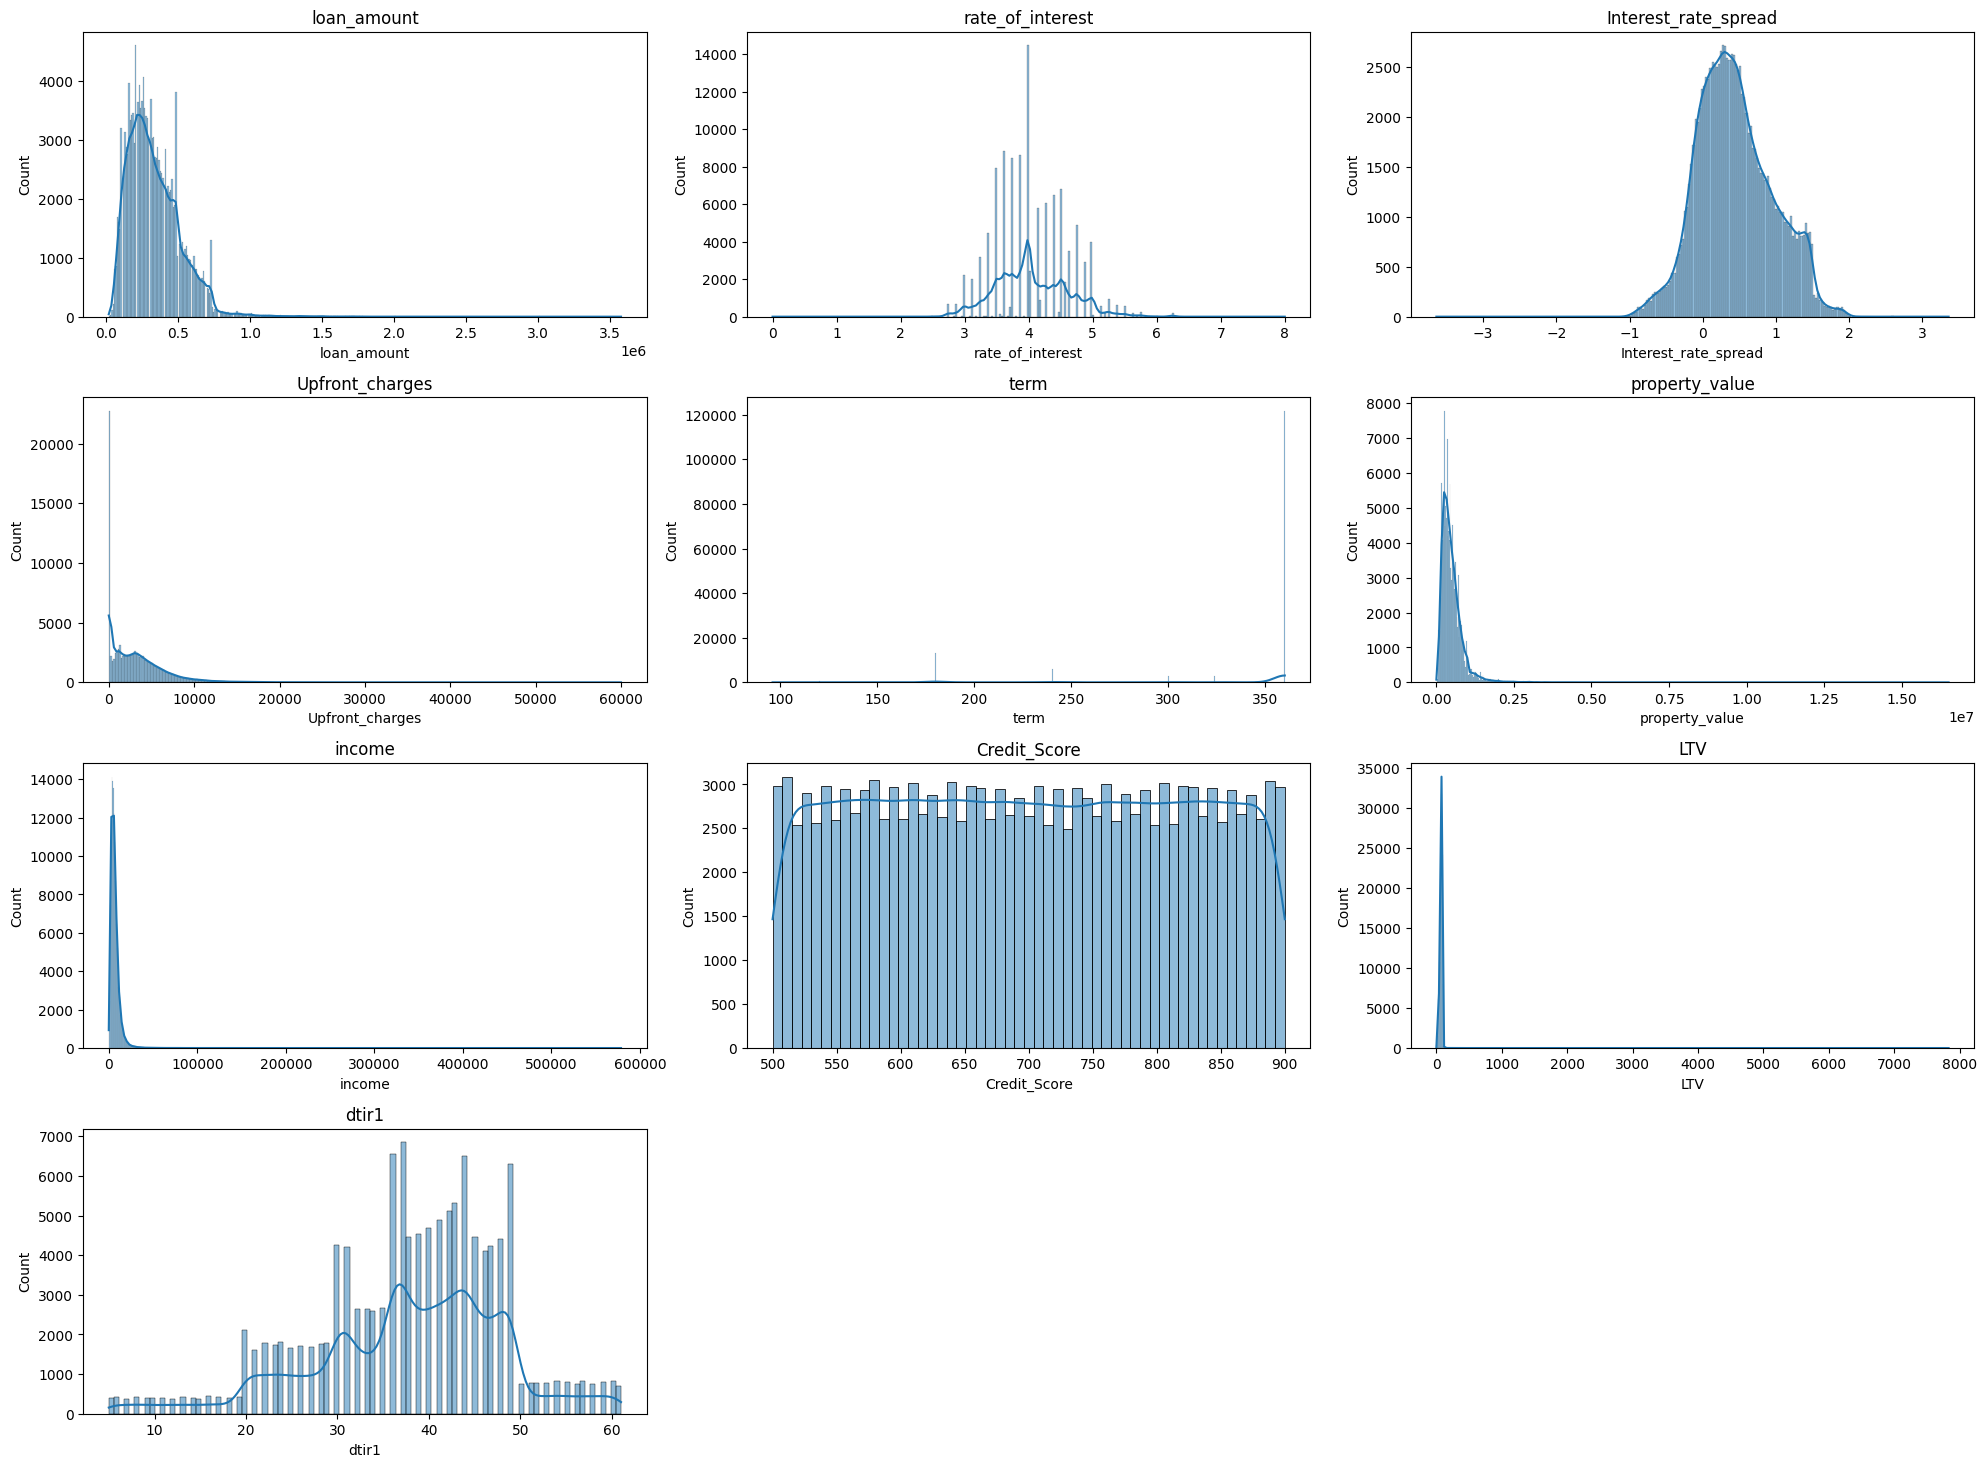

In [25]:
plt.figure(figsize=(20, 18))

num_plot_cols = num_cols.drop(['ID', 'year', 'Status'])
for i, col in enumerate(num_plot_cols):
    plt.subplot(5, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

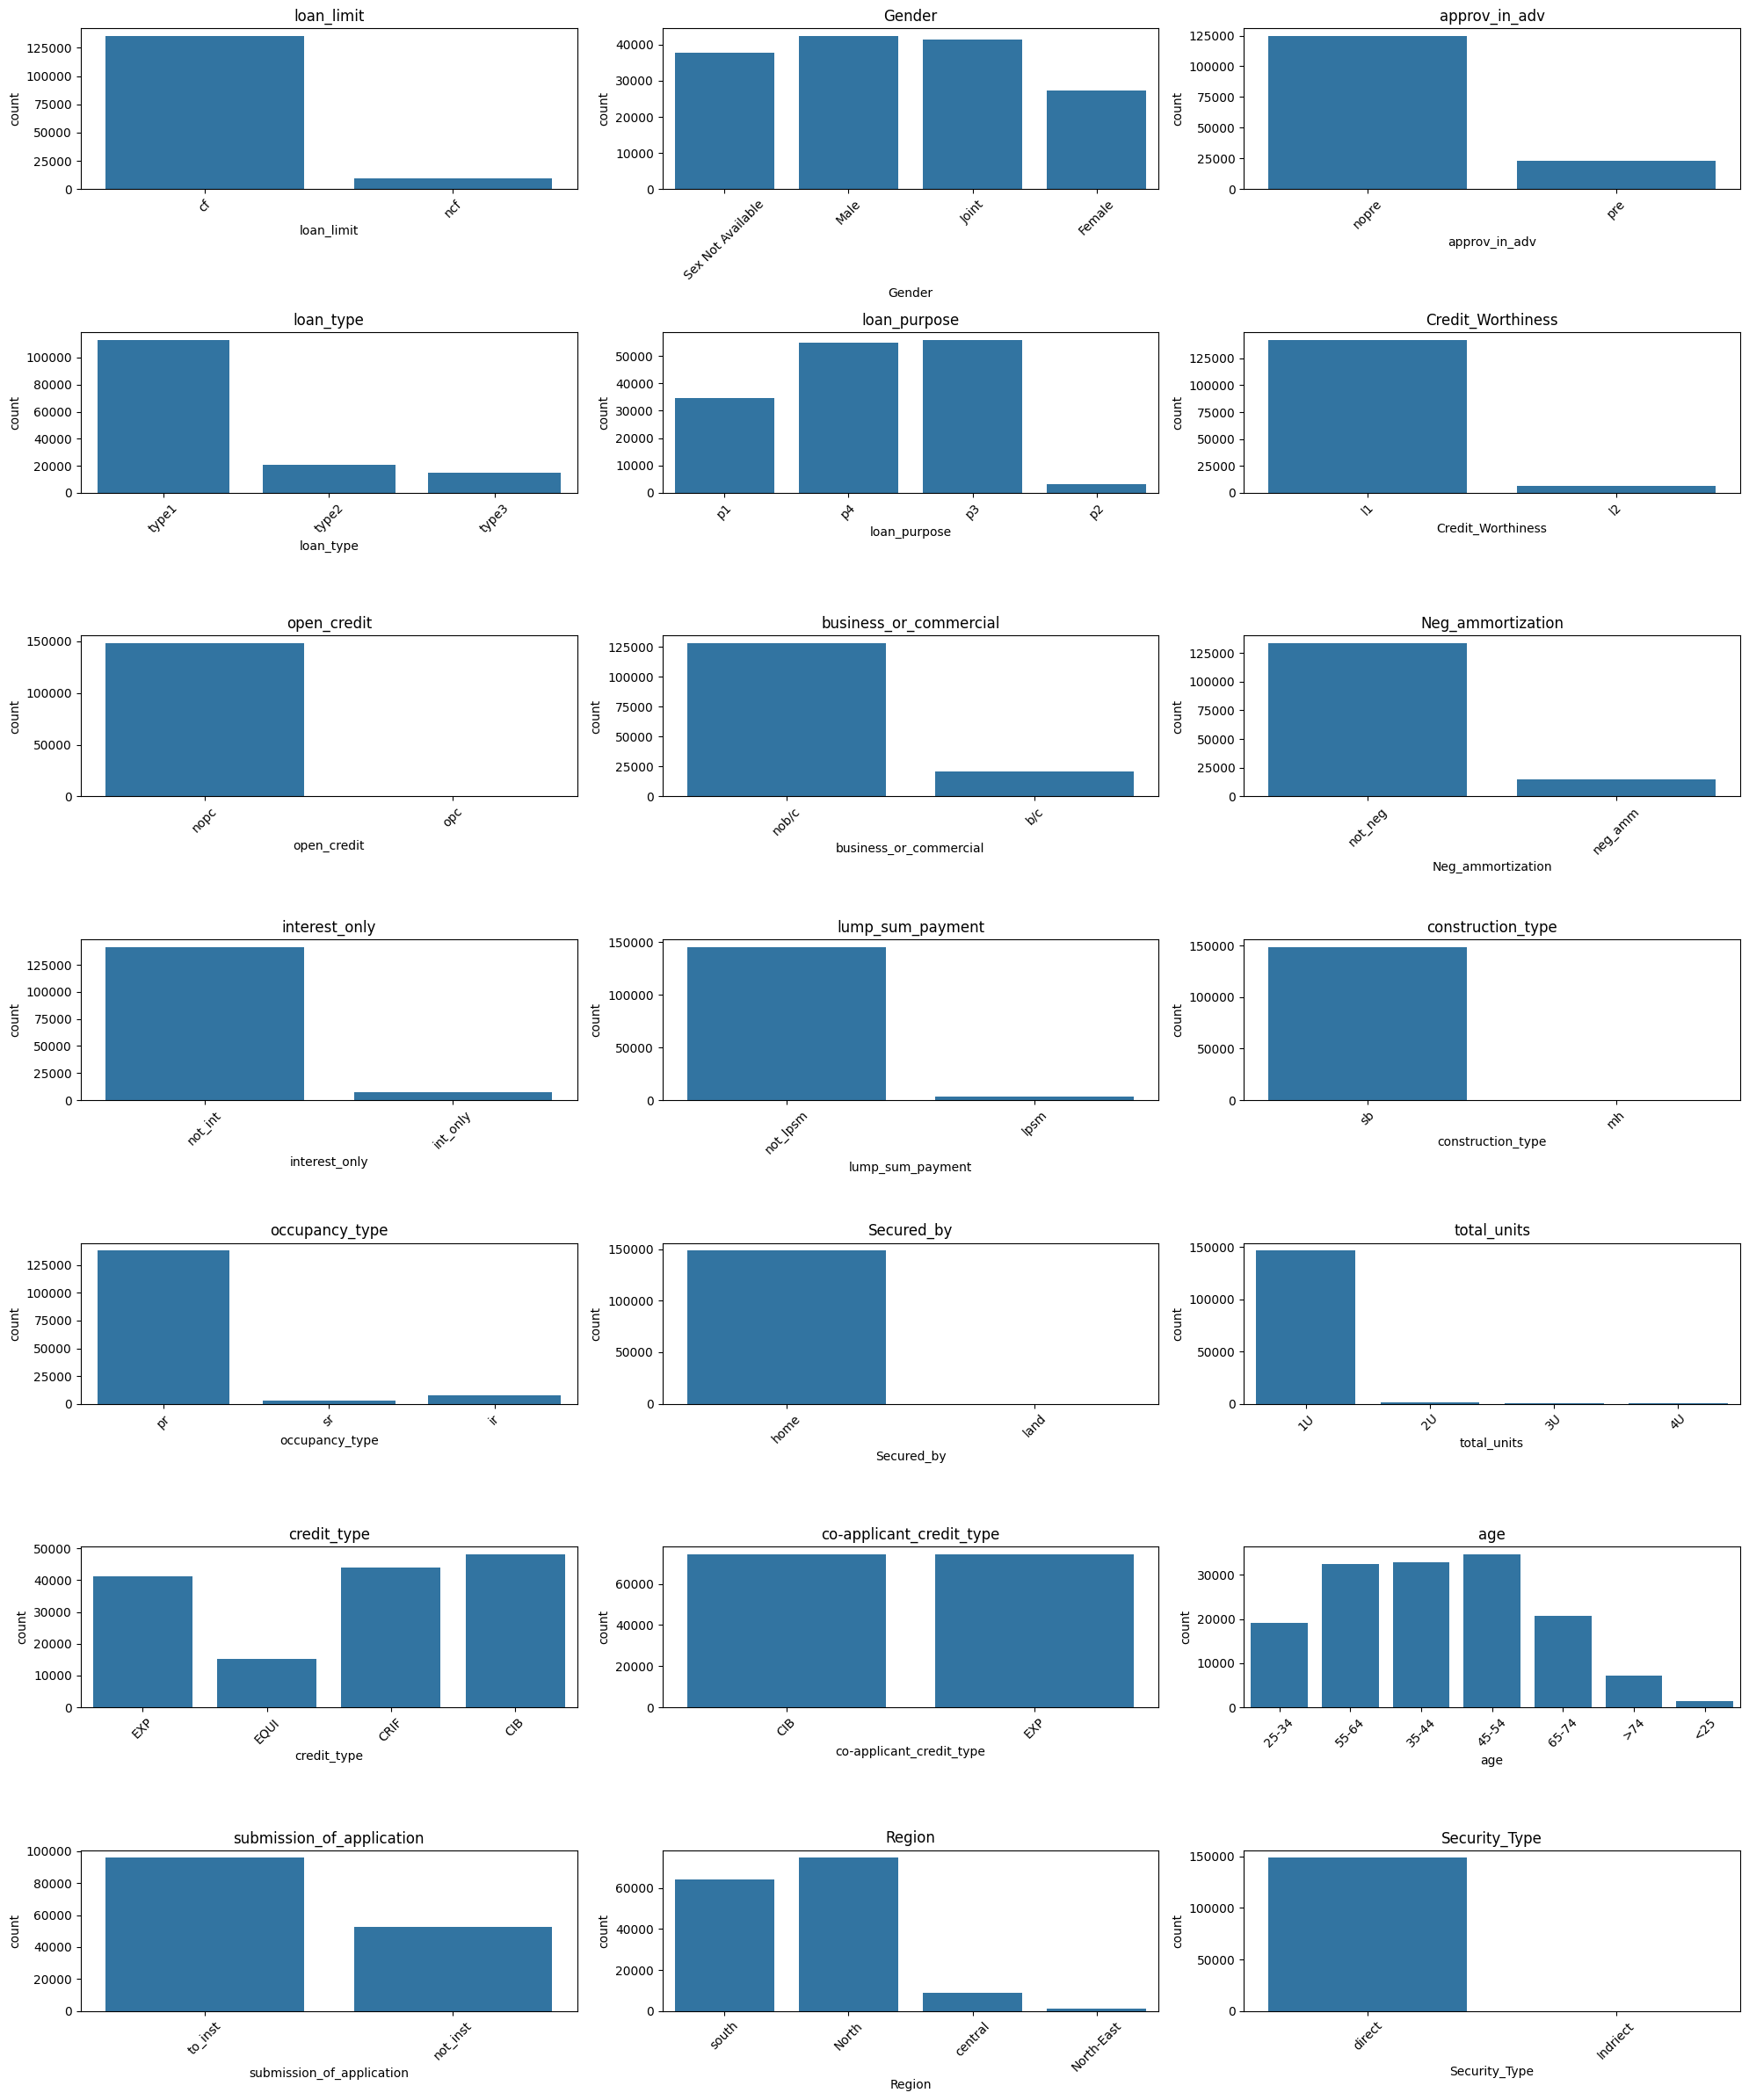

In [26]:
plt.figure(figsize=(20, 24))

for i, col in enumerate(cat_cols):
    plt.subplot(7, 3, i + 1)
    sns.countplot(x=df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Target Varibale count plot

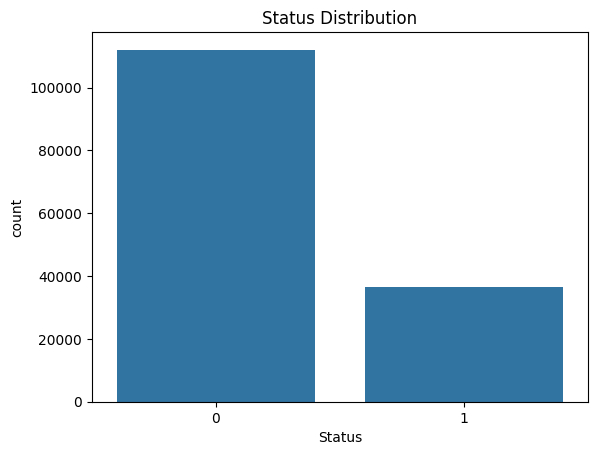

In [27]:
sns.countplot(x=df['Status'])
plt.title('Status Distribution')
plt.show()

#Outliers

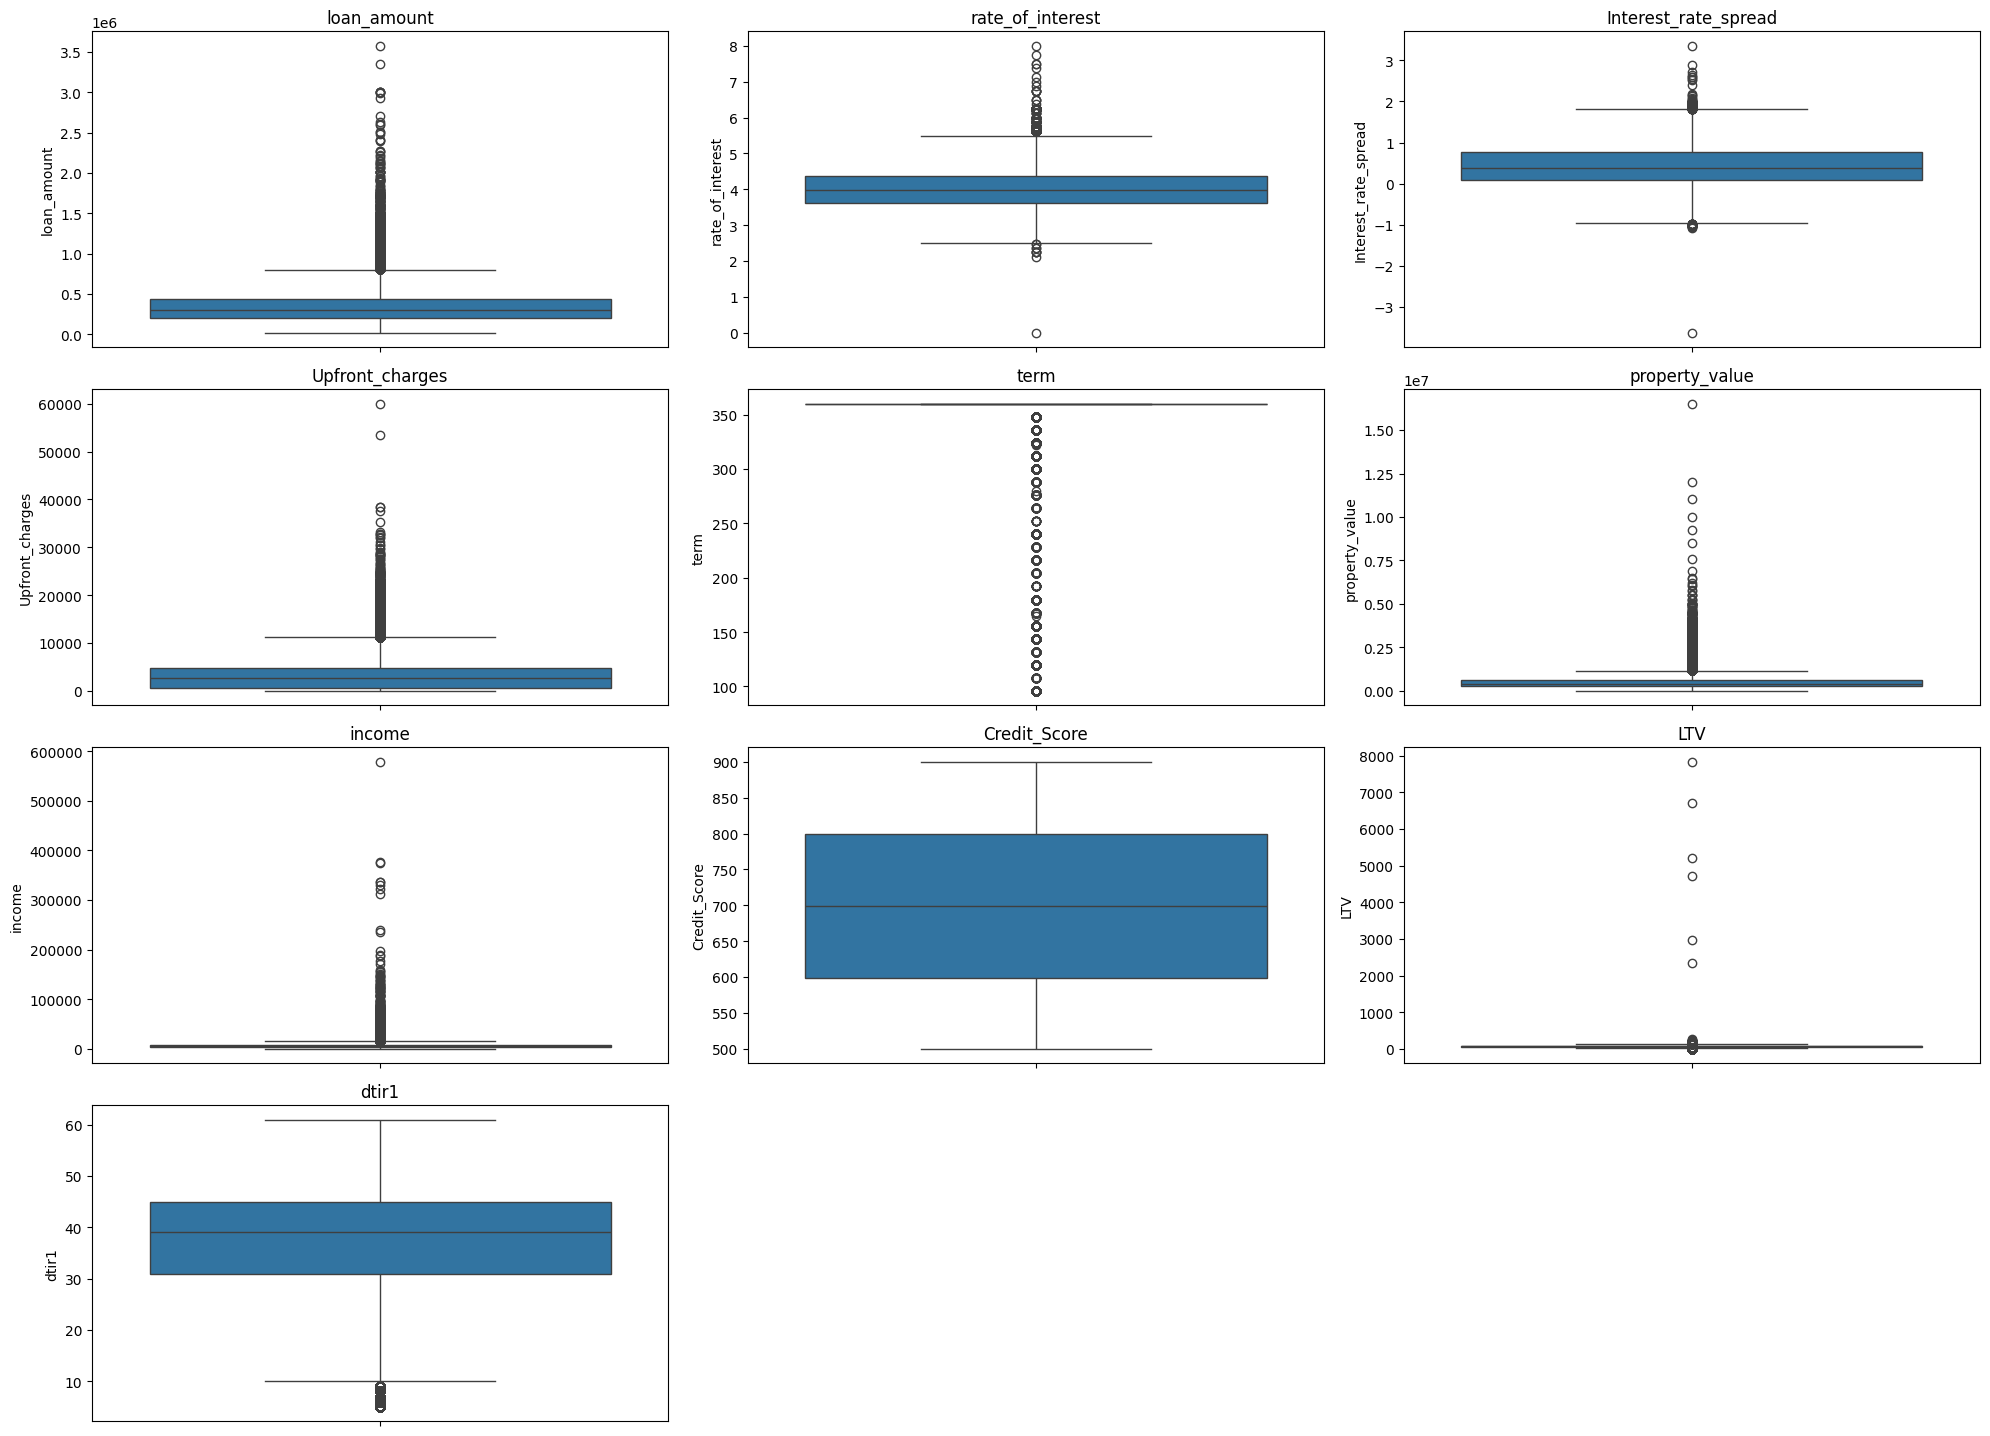

In [46]:
plt.figure(figsize=(20, 18))

num_plot_cols = num_cols.drop(['ID', 'year', 'Status'])
for i, col in enumerate(num_plot_cols):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#extreme outliers can distort the graph's scale and make the central data look compressed.

# Data Cleaning

#numerical columns were adjusted by median

In [28]:
df['rate_of_interest'] = df['rate_of_interest'].fillna(df['rate_of_interest'].median())

df['Interest_rate_spread'] = df['Interest_rate_spread'].fillna(df['Interest_rate_spread'].median())

df['Upfront_charges'] = df['Upfront_charges'].fillna(df['Upfront_charges'].median())

df['dtir1'] = df['dtir1'].fillna(df['dtir1'].median())

df['property_value'] = df['property_value'].fillna(df['property_value'].median())

df['LTV'] = df['LTV'].fillna(df['LTV'].median())

df['income'] = df['income'].fillna(df['income'].median())

df['term'] = df['term'].fillna(df['term'].median())

#For categorical columns with missing values, use mode

In [29]:
df['loan_limit'] = df['loan_limit'].fillna(df['loan_limit'].mode()[0])

df['approv_in_adv'] = df['approv_in_adv'].fillna(df['approv_in_adv'].mode()[0])

df['loan_purpose'] = df['loan_purpose'].fillna(df['loan_purpose'].mode()[0])

df['Neg_ammortization'] = df['Neg_ammortization'].fillna(df['Neg_ammortization'].mode()[0])

df['age'] = df['age'].fillna(df['age'].mode()[0])

df['submission_of_application'] = df['submission_of_application'].fillna(
    df['submission_of_application'].mode()[0]
)

In [30]:
df.isnull().sum()

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

#Check for duplicated rows

In [31]:
df.duplicated().sum()

np.int64(0)

#Checking data types are correct

In [32]:
df.dtypes

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

#Handling in-consistent categories if any

In [33]:
for col in cat_cols:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre']
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
age : ['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25']
submission_of_application : ['to_inst' 'not_inst']
Region : ['south' 'North' 'central' 'North-East']
Security_Type : ['direct' 'Indriect']


In [34]:
#Region has mixed capitalization: south, North, central, North-East
#Security_Type has Indriect, which looks like a typo for Indirect
#construction_type has ' sb' with a leading space, while 'mh' does not
#Some categories use cryptic abbreviations like pr, sr, ir, but those are not inconsistencies by themselves 
#so we need a quick fix

In [35]:
df['Region'] = df['Region'].str.title()
df['Security_Type'] = df['Security_Type'].replace('Indriect', 'Indirect')
for col in cat_cols:
    df[col] = df[col].str.strip()

In [36]:
for col in cat_cols:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
Gender : ['Sex Not Available' 'Male' 'Joint' 'Female']
approv_in_adv : ['nopre' 'pre']
loan_type : ['type1' 'type2' 'type3']
loan_purpose : ['p1' 'p4' 'p3' 'p2']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
age : ['25-34' '55-64' '35-44' '45-54' '65-74' '>74' '<25']
submission_of_application : ['to_inst' 'not_inst']
Region : ['South' 'North' 'Central' 'North-East']
Security_Type : ['direct' 'Indirect']


#Checing for fix logic and domain errors:

In [37]:
# Domain / logical validation checks

print("loan_amount <= 0:", (df['loan_amount'] <= 0).sum())

print("property_value <= 0:", (df['property_value'] <= 0).sum())

print("income < 0:", (df['income'] < 0).sum())

print("rate_of_interest < 0:", (df['rate_of_interest'] < 0).sum())

print("term <= 0:", (df['term'] <= 0).sum())

print("LTV < 0:", (df['LTV'] < 0).sum())

print("dtir1 < 0:", (df['dtir1'] < 0).sum())

print("Invalid Status values:",
      (~df['Status'].isin([0, 1])).sum())

loan_amount <= 0: 0
property_value <= 0: 0
income < 0: 0
rate_of_interest < 0: 0
term <= 0: 0
LTV < 0: 0
dtir1 < 0: 0
Invalid Status values: 0


In [38]:
(df['income'] == 0).sum()


np.int64(1260)

In [39]:
df.nlargest(10, 'LTV')[['loan_amount', 'property_value', 'LTV']]

,loan_amount,property_value,LTV
16951,626500,8000.0,7831.250000
55286,536500,8000.0,6706.250000
47807,416500,8000.0,5206.250000
65238,376500,8000.0,4706.250000
46287,236500,8000.0,2956.250000
123343,186500,8000.0,2331.250000
43348,126500,48000.0,263.541667
27473,66500,28000.0,237.500000
30837,66500,28000.0,237.500000
136154,546500,248000.0,220.362903


#Extreme LTV values were identified. Examination showed that they result from very low property values relative to loan amounts. Since the LTV calculations are internally consistent and there is insufficient evidence that these records are wrong, they were retained.

#handling, detect outliers with IQR

In [40]:
for col in num_plot_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(col, ":", len(outliers))
# Outliers were detected using the IQR method.
# Since statistical outliers are not necessarily invalid values
# and no clear evidence of erroneous records was found,
# the outliers were retained.

loan_amount : 1895
rate_of_interest : 6817
Interest_rate_spread : 11478
Upfront_charges : 8915
term : 26944
property_value : 6596
income : 7636
Credit_Score : 0
LTV : 4671
dtir1 : 5508


# Data Pre-processing

In [41]:
#Label Enconding
age_mapping = {
    '<25': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55-64': 4,
    '65-74': 5,
    '>74': 6
}

df['age'] = df['age'].map(age_mapping)

In [42]:
#One hot-encoding
df = pd.get_dummies(
    df,
    columns=['Gender', 'loan_type', 'loan_purpose', 'Region'],
    dtype=int
)

In [43]:
df.shape

(148670, 45)

In [44]:
# Categories remainig 
for col in df.select_dtypes(include=['object']).columns:
    print(col, ":", df[col].unique())

loan_limit : ['cf' 'ncf']
approv_in_adv : ['nopre' 'pre']
Credit_Worthiness : ['l1' 'l2']
open_credit : ['nopc' 'opc']
business_or_commercial : ['nob/c' 'b/c']
Neg_ammortization : ['not_neg' 'neg_amm']
interest_only : ['not_int' 'int_only']
lump_sum_payment : ['not_lpsm' 'lpsm']
construction_type : ['sb' 'mh']
occupancy_type : ['pr' 'sr' 'ir']
Secured_by : ['home' 'land']
total_units : ['1U' '2U' '3U' '4U']
credit_type : ['EXP' 'EQUI' 'CRIF' 'CIB']
co-applicant_credit_type : ['CIB' 'EXP']
submission_of_application : ['to_inst' 'not_inst']
Security_Type : ['direct' 'Indirect']


In [45]:
# One-Hot Encoding remaining nominal columns
df = pd.get_dummies(
    df,
    columns=[
        'occupancy_type',
        'total_units',
        'credit_type'
    ],
    dtype=int
)

In [46]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    'loan_limit',
    'approv_in_adv',
    'Credit_Worthiness',
    'open_credit',
    'business_or_commercial',
    'Neg_ammortization',
    'interest_only',
    'lump_sum_payment',
    'construction_type',
    'Secured_by',
    'co-applicant_credit_type',
    'submission_of_application',
    'Security_Type'
]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [48]:
df.shape

(148670, 53)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 53 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 148670 non-null  int64  
 3   approv_in_adv              148670 non-null  int64  
 4   Credit_Worthiness          148670 non-null  int64  
 5   open_credit                148670 non-null  int64  
 6   business_or_commercial     148670 non-null  int64  
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           148670 non-null  float64
 9   Interest_rate_spread       148670 non-null  float64
 10  Upfront_charges            148670 non-null  float64
 11  term                       148670 non-null  float64
 12  Neg_ammortization          148670 non-null  int64  
 13  interest_only              14

# Feature Engineering and Selection

In [85]:
# Remove non-informative features
df = df.drop(columns=['ID', 'year'])

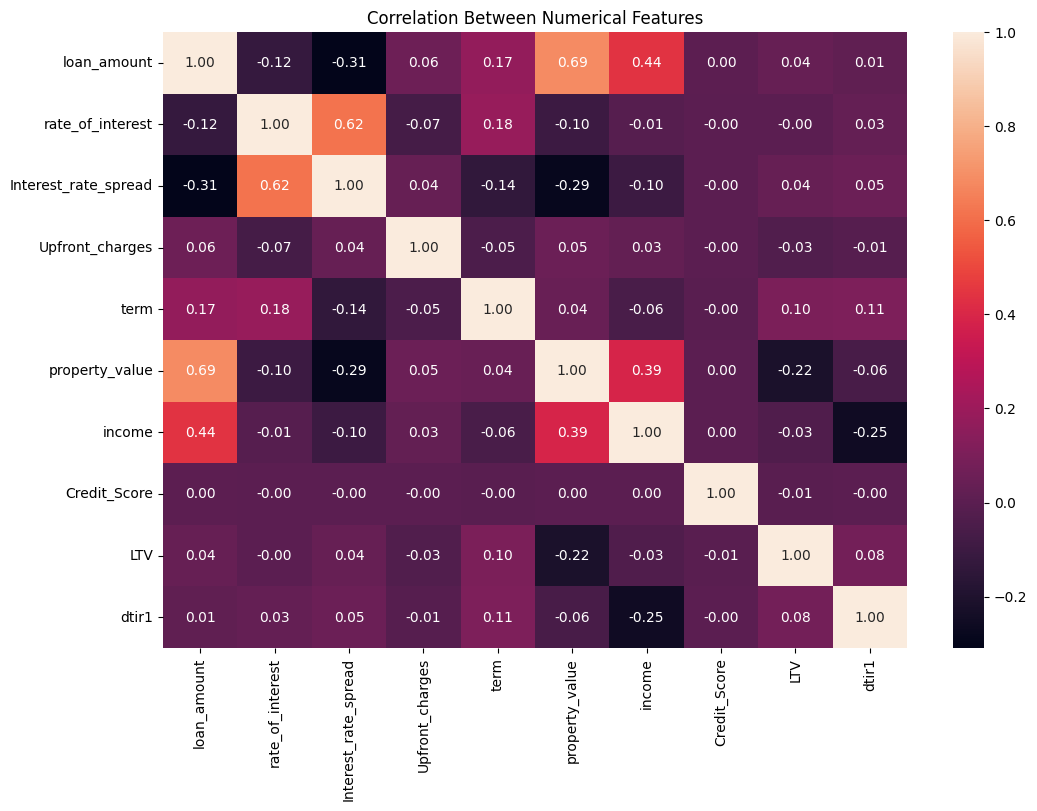

In [87]:
#Pearson correlation
num_features = [
    'loan_amount',
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'term',
    'property_value',
    'income',
    'Credit_Score',
    'LTV',
    'dtir1'
]
corr = df[num_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Between Numerical Features')
plt.show()

In [88]:
# No numerical features were removed based on Pearson correlation,
# as no extremely high correlation was observed between feature pairs.

In [90]:
# Chi-Square Test: Categorical Features vs Target

from sklearn.feature_selection import chi2

categorical_features = [
    col for col in df.columns
    if col not in num_features + ['Status', 'ID', 'year', 'age']
]

X_cat = df[categorical_features]
y = df['Status']

chi_scores, p_values = chi2(X_cat, y)

chi_results = pd.DataFrame({
    'Feature': categorical_features,
    'Chi2 Score': chi_scores,
    'P-value': p_values
}).sort_values('P-value')

chi_results
#age is excluded because it is ordianl categorical

,Feature,Chi2 Score,P-value
10,co-applicant_credit_type,1547.716853,0.000000e+00
37,credit_type_EQUI,46768.550203,0.000000e+00
38,credit_type_EXP,1668.258891,0.000000e+00
35,credit_type_CIB,2026.387377,0.000000e+00
36,credit_type_CRIF,1672.084234,0.000000e+00
18,loan_type_type2,1095.591344,2.999734e-240
11,submission_of_application,789.008599,1.323763e-173
14,Gender_Joint,669.987977,1.005125e-147
0,loan_limit,394.478592,8.767916e-88
5,Neg_ammortization,367.402090,6.884066e-82


In [91]:
# ANOVA F-Test: Numerical Features vs Categorical Target

from sklearn.feature_selection import f_classif

X_num = df[num_features]
y = df['Status']

f_scores, p_values = f_classif(X_num, y)

anova_results = pd.DataFrame({
    'Feature': num_features,
    'F-Score': f_scores,
    'P-value': p_values
}).sort_values('P-value')

anova_results

,Feature,F-Score,P-value
3,Upfront_charges,1356.639214,1.210288e-295
9,dtir1,1017.125659,1.929235e-222
5,property_value,979.534921,2.522136e-214
6,income,548.304344,4.882970e-121
2,Interest_rate_spread,365.694332,2.031071e-81
1,rate_of_interest,325.461313,1.119591e-72
8,LTV,270.997568,7.788582e-61
0,loan_amount,201.882585,8.690628e-46
7,Credit_Score,2.383121,1.226544e-01
4,term,0.006385,9.363109e-01


In [52]:
# Feature Selection Insights:
# 1. Pearson correlation showed no extremely high correlation among numerical features.
# 2. Chi-square showed significant associations for most categorical features,
#    while construction_type and Security_Type showed weak/no significant association.
# 3. ANOVA showed significant differences for most numerical features,
#    while term and Credit_Score were not statistically significant.
# 4. Weak features were identified as candidates rather than automatically removed,
#    because univariate statistical tests alone may not capture their combined
#    predictive value in a machine learning model.

# Train-test split

In [54]:
#Separate features (X) and target (y)
X = df.drop('Status', axis=1)
y = df['Status']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#X_train → fit_transform() 
          #↑
#Scaler LEARNS mean & standard deviation from TRAINING data

#X_test → transform()
        # ↑
#Uses the SAME learned values 
#This practice prevents Data Leakage

# Models Performance

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

In [62]:
models = {
    "Logistic Regression": (LogisticRegression(), True),
    "KNN": (KNeighborsClassifier(), True),
    "Naive Bayes": (GaussianNB(), False),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), False),
    #"SVM": (SVC(), True)
}

In [72]:
results = {}
predictions = {}

for name, (model, needs_scaling) in models.items():

    print("Training:", name)

    if needs_scaling:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Train
    model.fit(X_tr, y_train)

    # Predict
    y_pred = model.predict(X_te)

    # Save predictions
    predictions[name] = y_pred

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Save each model's result
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


Training: Logistic Regression
Training: KNN
Training: Naive Bayes
Training: Decision Tree


# Evaluation Metrics

In [73]:
results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1
Logistic Regression,0.874184,0.930406,0.529067,0.674554
KNN,0.891404,0.836923,0.694733,0.759227
Naive Bayes,0.925708,0.772606,0.989902,0.867859
Decision Tree,1.000000,1.000000,1.000000,1.000000


# Investigating Suspicious behaviour of Decision Tree

In [74]:
#Check Decision Tree's training vs testing performance:

In [75]:
print("Training Accuracy:", models["Decision Tree"][0].score(X_train, y_train))
print("Testing Accuracy:", models["Decision Tree"][0].score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [77]:
#Results shows Decision Tree have no overfitting or underfitting
df.corr(numeric_only=True)['Status'].sort_values(ascending=False)

Status                       1.000000
credit_type_EQUI             0.592168
co-applicant_credit_type     0.144239
submission_of_application    0.122410
loan_type_type2              0.092550
dtir1                        0.082432
Gender_Sex Not Available     0.053336
loan_limit                   0.053332
age                          0.044280
LTV                          0.042656
Region_South                 0.040051
Credit_Worthiness            0.034875
loan_purpose_p2              0.029369
occupancy_type_ir            0.028249
Secured_by                   0.026055
total_units_2U               0.022978
Gender_Male                  0.022653
Region_Central               0.016738
total_units_3U               0.016460
loan_purpose_p1              0.015728
Region_North-East            0.012320
occupancy_type_sr            0.008468
loan_purpose_p3              0.006870
total_units_4U               0.005435
Gender_Female                0.005180
Credit_Score                 0.004004
loan_type_ty

In [78]:
tree_model = models["Decision Tree"][0]

feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

Interest_rate_spread      0.651373
credit_type_EQUI          0.348084
Upfront_charges           0.000452
rate_of_interest          0.000045
dtir1                     0.000045
loan_limit                0.000000
approv_in_adv             0.000000
Credit_Worthiness         0.000000
loan_amount               0.000000
business_or_commercial    0.000000
dtype: float64

In [79]:
pd.crosstab(
    df['Interest_rate_spread'].isna(),
    df['Status'],
    normalize='index'
)

Status,0,1
Interest_rate_spread,,
False,0.753555,0.246445


In [80]:
median_value = df['Interest_rate_spread'].median()

pd.crosstab(
    df['Interest_rate_spread'] == median_value,
    df['Status'],
    normalize='index'
)

Status,0,1
Interest_rate_spread,,
False,1.0000,0.0000
True,0.0003,0.9997


In [82]:
#Right now the tree is correctly learning the pattern present in your processed dataset.
#We need to determine whether that pattern is legitimate or an artifact of our preprocessing.

In [83]:
raw_df = pd.read_csv("Loan_Default.csv")
pd.crosstab(
    raw_df['Interest_rate_spread'].isna(),
    raw_df['Status'],
    normalize='index'
)

Status,0,1
Interest_rate_spread,,
False,1.0,0.0
True,0.0,1.0


In [84]:
#SO now we haave proved that in our original dataset
#Interest_rate_spread has value → Status = 0
#Interest_rate_spread missing   → Status = 1

In [85]:
# ============================================================
# EXPERIMENT 1: Remove possible leakage feature
# ============================================================
# Why?
# In the raw dataset, missingness in Interest_rate_spread
# perfectly matched Status, so this feature may leak the target.
# We remove ONLY this feature and keep everything else the same.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Remove only the suspicious feature
X_exp1 = df.drop(columns=['Status', 'Interest_rate_spread'])
y_exp1 = df['Status']

# 2. Train-test split
X_train_exp1, X_test_exp1, y_train_exp1, y_test_exp1 = train_test_split(
    X_exp1,
    y_exp1,
    test_size=0.2,
    random_state=42,
    stratify=y_exp1
)

# 3. Create scaled versions
scaler_exp1 = StandardScaler()

X_train_scaled_exp1 = scaler_exp1.fit_transform(X_train_exp1)
X_test_scaled_exp1 = scaler_exp1.transform(X_test_exp1)

# 4. Train and evaluate all models
results_exp1 = {}

for name, (model, needs_scaling) in models.items():

    print("Training:", name)

    if needs_scaling:
        X_tr = X_train_scaled_exp1
        X_te = X_test_scaled_exp1
    else:
        X_tr = X_train_exp1
        X_te = X_test_exp1

    model.fit(X_tr, y_train_exp1)
    y_pred = model.predict(X_te)

    results_exp1[name] = {
        "Accuracy": accuracy_score(y_test_exp1, y_pred),
        "Precision": precision_score(y_test_exp1, y_pred),
        "Recall": recall_score(y_test_exp1, y_pred),
        "F1": f1_score(y_test_exp1, y_pred)
    }

# 5. Show experiment results
results_exp1_df = pd.DataFrame(results_exp1).T
results_exp1_df

Training: Logistic Regression
Training: KNN
Training: Naive Bayes
Training: Decision Tree


,Accuracy,Precision,Recall,F1
Logistic Regression,0.873411,0.934211,0.523199,0.670749
KNN,0.872436,0.815343,0.623635,0.706719
Naive Bayes,0.925742,0.772689,0.989902,0.867911
Decision Tree,0.994787,0.990026,0.988810,0.989418


In [86]:
#Status relation with credits
# Check how credit_type_EQUI is related to the target
pd.crosstab(
    df['credit_type_EQUI'],
    df['Status'],
    normalize='index'
)

Status,0,1
credit_type_EQUI,,
0,0.839981,0.160019
1,0.000065,0.999935


In [87]:
# Check original credit_type categories against Status
pd.crosstab(
    raw_df['credit_type'],
    raw_df['Status'],
    normalize='index'
)

Status,0,1
credit_type,,
CIB,0.841959,0.158041
CRIF,0.837657,0.162343
EQUI,0.000065,0.999935
EXP,0.840146,0.159854


In [88]:
# Check relationship between EQUI credit type
# and missing Interest_rate_spread

pd.crosstab(
    raw_df['credit_type'] == 'EQUI',
    raw_df['Interest_rate_spread'].isna(),
    normalize='index'
)

Interest_rate_spread,False,True
credit_type,,
False,0.839981,0.160019
True,0.000065,0.999935


In [89]:
# ============================================================
# EXPERIMENT 2: Remove both strongly connected target clues
# ============================================================
# Findings:
# 1. Missing Interest_rate_spread → almost perfectly identifies Status = 1
# 2. credit_type = EQUI → almost always has missing Interest_rate_spread
# 3. Therefore, credit_type_EQUI provides almost the same shortcut.
#
# Goal:
# Remove BOTH and see whether model performance becomes more realistic.

# 1. Remove target + two suspicious features
X_exp2 = df.drop(
    columns=['Status', 'Interest_rate_spread', 'credit_type_EQUI']
)

y_exp2 = df['Status']


# 2. Train-test split
X_train_exp2, X_test_exp2, y_train_exp2, y_test_exp2 = train_test_split(
    X_exp2,
    y_exp2,
    test_size=0.2,
    random_state=42,
    stratify=y_exp2
)


# 3. Scaling
scaler_exp2 = StandardScaler()

X_train_scaled_exp2 = scaler_exp2.fit_transform(X_train_exp2)
X_test_scaled_exp2 = scaler_exp2.transform(X_test_exp2)


# 4. Train + evaluate models
results_exp2 = {}

for name, (model, needs_scaling) in models.items():

    print("Training:", name)

    if needs_scaling:
        X_tr = X_train_scaled_exp2
        X_te = X_test_scaled_exp2
    else:
        X_tr = X_train_exp2
        X_te = X_test_exp2

    model.fit(X_tr, y_train_exp2)
    y_pred = model.predict(X_te)

    results_exp2[name] = {
        "Accuracy": accuracy_score(y_test_exp2, y_pred),
        "Precision": precision_score(y_test_exp2, y_pred),
        "Recall": recall_score(y_test_exp2, y_pred),
        "F1": f1_score(y_test_exp2, y_pred)
    }


# 5. Display results
results_exp2_df = pd.DataFrame(results_exp2).T
results_exp2_df

Training: Logistic Regression
Training: KNN
Training: Naive Bayes
Training: Decision Tree


,Accuracy,Precision,Recall,F1
Logistic Regression,0.873344,0.933967,0.523062,0.670574
KNN,0.866752,0.782383,0.636326,0.701836
Naive Bayes,0.925742,0.772630,0.990038,0.867927
Decision Tree,0.994384,0.989340,0.987855,0.988597


In [90]:
# Find which features Decision Tree relies on
# AFTER removing Interest_rate_spread and credit_type_EQUI

tree_exp2 = models["Decision Tree"][0]

feature_importance_exp2 = pd.Series(
    tree_exp2.feature_importances_,
    index=X_exp2.columns
).sort_values(ascending=False)

feature_importance_exp2.head(10)

Upfront_charges             0.889608
rate_of_interest            0.090705
ID                          0.002398
income                      0.001999
LTV                         0.001749
Credit_Score                0.001727
business_or_commercial      0.001388
Gender_Sex Not Available    0.001287
Neg_ammortization           0.001109
property_value              0.001096
dtype: float64

In [91]:
# Check whether missing Upfront_charges is related to Status
pd.crosstab(
    raw_df['Upfront_charges'].isna(),
    raw_df['Status'],
    normalize='index'
)

Status,0,1
Upfront_charges,,
False,0.998597,0.001403
True,0.079613,0.920387


In [92]:
# ============================================================
# MISSINGNESS vs TARGET ANALYSIS
# ============================================================
# Goal:
# Check whether missing values in ANY column are strongly
# associated with Status = 1.

missing_analysis = []

for col in raw_df.columns:

    # Only check columns that originally contain missing values
    if raw_df[col].isna().sum() > 0:

        missing_rows = raw_df[raw_df[col].isna()]

        # Among rows where this feature is missing,
        # calculate the percentage having Status = 1
        status_1_rate = missing_rows['Status'].mean()

        missing_analysis.append({
            "Feature": col,
            "Missing_Count": raw_df[col].isna().sum(),
            "Status_1_When_Missing": status_1_rate
        })

# Convert results into a table
missing_analysis_df = pd.DataFrame(missing_analysis)

# Show strongest relationships first
missing_analysis_df = missing_analysis_df.sort_values(
    by="Status_1_When_Missing",
    ascending=False
)

missing_analysis_df

,Feature,Missing_Count,Status_1_When_Missing
4,Interest_rate_spread,36639,1.000000
3,rate_of_interest,36439,1.000000
10,age,200,1.000000
11,submission_of_application,200,1.000000
12,LTV,15098,0.999868
8,property_value,15098,0.999868
5,Upfront_charges,39642,0.920387
13,dtir1,24121,0.676174
6,term,41,0.365854
1,approv_in_adv,908,0.265419


In [93]:
# ============================================================
# EXPERIMENT 3: Remove ID
# ============================================================
# Hypothesis:
# ID is only a unique identifier and should not provide
# meaningful information for predicting loan Status.
#
# Goal:
# Check whether removing ID affects model performance.

# 1. Remove ID from features
X_exp3 = df.drop(columns=['Status', 'ID'])
y_exp3 = df['Status']

# 2. Train-test split
X_train_exp3, X_test_exp3, y_train_exp3, y_test_exp3 = train_test_split(
    X_exp3,
    y_exp3,
    test_size=0.2,
    random_state=42,
    stratify=y_exp3
)

# 3. Scaling
scaler_exp3 = StandardScaler()

X_train_scaled_exp3 = scaler_exp3.fit_transform(X_train_exp3)
X_test_scaled_exp3 = scaler_exp3.transform(X_test_exp3)

# 4. Train + Evaluate
results_exp3 = {}

for name, (model, needs_scaling) in models.items():

    if needs_scaling:
        X_tr = X_train_scaled_exp3
        X_te = X_test_scaled_exp3
    else:
        X_tr = X_train_exp3
        X_te = X_test_exp3

    model.fit(X_tr, y_train_exp3)
    y_pred = model.predict(X_te)

    results_exp3[name] = {
        "Accuracy": accuracy_score(y_test_exp3, y_pred),
        "Precision": precision_score(y_test_exp3, y_pred),
        "Recall": recall_score(y_test_exp3, y_pred),
        "F1": f1_score(y_test_exp3, y_pred)
    }

# 5. Display
results_exp3_df = pd.DataFrame(results_exp3).T
results_exp3_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.874184,0.930406,0.529067,0.674554
KNN,0.895608,0.833333,0.720524,0.772834
Naive Bayes,0.925708,0.772606,0.989902,0.867859
Decision Tree,1.000000,1.000000,1.000000,1.000000


#Removing ID had almost no effect on Logistic Regression and Naive Bayes, but improved KNN recall and F1. This suggests ID was an irrelevant feature that slightly distorted KNN's distance calculations.

#And importantly: keep ID removed for our next experiments. This was a sensible feature-selection decision, not just chasing a higher score.

In [94]:
# ============================================================
# EXPERIMENT 4: Remove ID + Year
# ============================================================
# Why?
# ID   -> only identifies each record; no real loan meaning.
# Year -> constant (2019) for all rows, so it cannot help
#         distinguish Status 0 from Status 1.
#
# Goal:
# Remove logically useless features and observe whether
# model performance changes.

# 1. Remove target + ID + year
X_exp4 = df.drop(columns=['Status', 'ID', 'year'])
y_exp4 = df['Status']

# 2. Train-test split
X_train_exp4, X_test_exp4, y_train_exp4, y_test_exp4 = train_test_split(
    X_exp4,
    y_exp4,
    test_size=0.2,
    random_state=42,
    stratify=y_exp4
)

# 3. Create scaled versions
scaler_exp4 = StandardScaler()

X_train_scaled_exp4 = scaler_exp4.fit_transform(X_train_exp4)
X_test_scaled_exp4 = scaler_exp4.transform(X_test_exp4)

# 4. Train + evaluate
results_exp4 = {}

for name, (model, needs_scaling) in models.items():

    if needs_scaling:
        X_tr = X_train_scaled_exp4
        X_te = X_test_scaled_exp4
    else:
        X_tr = X_train_exp4
        X_te = X_test_exp4

    model.fit(X_tr, y_train_exp4)
    y_pred = model.predict(X_te)

    results_exp4[name] = {
        "Accuracy": accuracy_score(y_test_exp4, y_pred),
        "Precision": precision_score(y_test_exp4, y_pred),
        "Recall": recall_score(y_test_exp4, y_pred),
        "F1": f1_score(y_test_exp4, y_pred)
    }

# 5. Display results
results_exp4_df = pd.DataFrame(results_exp4).T
results_exp4_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.874184,0.930406,0.529067,0.674554
KNN,0.895608,0.833333,0.720524,0.772834
Naive Bayes,0.925708,0.772606,0.989902,0.867859
Decision Tree,1.000000,1.000000,1.000000,1.000000


In [95]:
# Check which features have the strongest influence
# on Logistic Regression predictions

lr_model = models["Logistic Regression"][0]

lr_importance = pd.Series(
    lr_model.coef_[0],
    index=X_exp4.columns
).sort_values(ascending=False)

lr_importance

credit_type_EQUI             3.021586
LTV                          0.662926
submission_of_application    0.633077
loan_limit                   0.188508
occupancy_type_ir            0.168668
loan_type_type2              0.126834
loan_purpose_p2              0.119872
loan_purpose_p3              0.116125
dtir1                        0.100536
loan_amount                  0.096284
Credit_Worthiness            0.094163
age                          0.091890
loan_type_type1              0.080945
property_value               0.062031
Secured_by                   0.054041
Region_Central               0.050143
total_units_2U               0.043044
Gender_Male                  0.037660
total_units_3U               0.034544
Region_South                 0.019200
Region_North-East            0.018719
Credit_Score                 0.016303
total_units_4U               0.009477
occupancy_type_sr           -0.000892
Gender_Sex Not Available    -0.002661
open_credit                 -0.004049
Gender_Femal

In [96]:
# ============================================================
# ANALYZE LOGISTIC REGRESSION FALSE NEGATIVES
# ============================================================

# Get Logistic Regression model
lr_model = models["Logistic Regression"][0]

# Predict using scaled Experiment 4 test data
lr_pred = lr_model.predict(X_test_scaled_exp4)

# Create a copy of original unscaled test features
lr_analysis = X_test_exp4.copy()

# Add actual and predicted Status
lr_analysis['Actual'] = y_test_exp4.values
lr_analysis['Predicted'] = lr_pred

# Separate True Positives and False Negatives
true_positives = lr_analysis[
    (lr_analysis['Actual'] == 1) &
    (lr_analysis['Predicted'] == 1)
]

false_negatives = lr_analysis[
    (lr_analysis['Actual'] == 1) &
    (lr_analysis['Predicted'] == 0)
]

print("True Positives:", len(true_positives))
print("False Negatives:", len(false_negatives))

True Positives: 3877
False Negatives: 3451


In [97]:
# ============================================================
# Compare TRUE POSITIVES vs FALSE NEGATIVES
# Logistic Regression
# ============================================================
# Goal:
# Find numerical features that look different between:
# TP = Status 1 correctly detected
# FN = Status 1 incorrectly missed

# Remove Actual and Predicted before comparison
feature_cols = X_test_exp4.select_dtypes(include='number').columns

comparison = pd.DataFrame({
    "TP_Mean": true_positives[feature_cols].mean(),
    "FN_Mean": false_negatives[feature_cols].mean()
})

# Calculate how different the two groups are
comparison["Difference"] = (
    comparison["TP_Mean"] - comparison["FN_Mean"]
).abs()

# Show features with biggest differences first
comparison.sort_values("Difference", ascending=False).head(15)

,TP_Mean,FN_Mean,Difference
property_value,420017.023472,471025.210084,51008.186612
loan_amount,322427.263348,322721.385106,294.121758
income,6355.419139,6322.045784,33.373355
Upfront_charges,2588.905213,2596.450000,7.544787
term,333.905597,338.166329,4.260731
Credit_Score,703.155017,699.027818,4.127199
credit_type_EQUI,0.809905,0.000000,0.809905
co-applicant_credit_type,0.864844,0.371197,0.493647
dtir1,39.495486,39.006665,0.488821
credit_type_CIB,0.071963,0.357288,0.285325


In [98]:
# ============================================================
# ANALYSIS: Non-EQUI Status=1 cases
# ============================================================
# Goal:
# Logistic Regression catches EQUI positives very well.
# Now compare multiple features among NON-EQUI Status=1 cases
# to understand why some are caught and others are missed.

# Keep only Non-EQUI positive cases
non_equi_tp = true_positives[
    true_positives['credit_type_EQUI'] == 0
]

non_equi_fn = false_negatives[
    false_negatives['credit_type_EQUI'] == 0
]

# Features we want to investigate TOGETHER
features_to_check = [
    'LTV',
    'property_value',
    'income',
    'loan_amount',
    'Credit_Score',
    'dtir1',
    'Upfront_charges',
    'rate_of_interest',
    'co-applicant_credit_type',
    'submission_of_application',
    'Neg_ammortization',
    'lump_sum_payment'
]

# Compare median instead of mean because several financial
# variables may contain extreme values/outliers
comparison_non_equi = pd.DataFrame({
    'Caught_TP': non_equi_tp[features_to_check].median(),
    'Missed_FN': non_equi_fn[features_to_check].median()
})

# Percentage difference makes features with different scales
# easier to compare than raw subtraction
comparison_non_equi['Percent_Difference'] = (
    abs(
        comparison_non_equi['Caught_TP']
        - comparison_non_equi['Missed_FN']
    )
    /
    comparison_non_equi['Missed_FN'].replace(0, np.nan)
    * 100
)

comparison_non_equi.sort_values(
    'Percent_Difference',
    ascending=False
)

,Caught_TP,Missed_FN,Percent_Difference
property_value,298000.000000,368000.000000,19.021739
loan_amount,236500.000000,276500.000000,14.466546
income,4320.000000,4980.000000,13.253012
dtir1,43.000000,40.000000,7.500000
LTV,82.303371,79.139434,3.997928
Credit_Score,709.000000,697.000000,1.721664
Upfront_charges,2596.450000,2596.450000,0.000000
rate_of_interest,3.990000,3.990000,0.000000
submission_of_application,1.000000,1.000000,0.000000
Neg_ammortization,1.000000,1.000000,0.000000
